# Mini-App: 2D Viscous Burgers' Equation
### CS555: Numerical Methods for PDEs — Spring 2026 Final Project

---

## 1. Statement of Problem

The **2D viscous Burgers' equations** form a coupled nonlinear system that combines advection (hyperbolic character) with diffusion (parabolic character):

$$
\frac{\partial u}{\partial t} + u\frac{\partial u}{\partial x} + v\frac{\partial u}{\partial y} = \nu\left(\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}\right)
$$

$$
\frac{\partial v}{\partial t} + u\frac{\partial v}{\partial x} + v\frac{\partial v}{\partial y} = \nu\left(\frac{\partial^2 v}{\partial x^2} + \frac{\partial^2 v}{\partial y^2}\right)
$$

on the domain $\Omega = [0,1]^2$ with viscosity $\nu > 0$.

**Why this problem?** Burgers' equation is the simplest PDE that retains the essential nonlinear advection structure of the Navier-Stokes equations. It serves as a fundamental testbed for studying:

- How **spatial discretization** (central vs. upwind) affects accuracy and stability
- How **time integration** (explicit vs. implicit, low- vs. high-order) trades off cost, accuracy, and stability
- How the **Reynolds number** $\text{Re} = UL/\nu$ controls solution sharpness and numerical difficulty
- The role of the **CFL condition** in constraining explicit methods

**Verification strategy:** The Cole-Hopf transformation provides an exact analytical solution, enabling rigorous convergence studies without reference-solution ambiguity.

## 2. Implementation Details

### 2.1 Exact Solution (Cole-Hopf)

The Cole-Hopf transformation $u = -2\nu\,\partial(\ln\phi)/\partial x$ reduces Burgers' equation to the linear heat equation. A known closed-form solution on $[0,1]^2$ is (Fletcher 1983, Bahadir 2003):

$$
u(x,y,t) = \frac{3}{4} - \frac{1}{4\left(1 + \exp\!\left(\frac{-4x + 4y - t}{32\nu}\right)\right)}, \qquad
v(x,y,t) = \frac{3}{4} + \frac{1}{4\left(1 + \exp\!\left(\frac{-4x + 4y - t}{32\nu}\right)\right)}
$$

Dirichlet boundary conditions are set from this exact solution at all times.

### 2.2 Spatial Discretization

On a uniform grid $h = 1/N$, two advection stencils are compared:

| Stencil | Formula for $u \,\phi_x$ | Order |
|---------|--------------------------|-------|
| **Central** | $u_{ij}\dfrac{\phi_{i+1,j} - \phi_{i-1,j}}{2h}$ | $O(h^2)$ |
| **Upwind** | $u_{ij}\dfrac{\phi_{ij} - \phi_{i-1,j}}{h}$ if $u_{ij}\ge 0$, else forward | $O(h)$ |

Diffusion uses the standard 5-point Laplacian (2nd order):
$$\nabla^2 \phi \approx \frac{\phi_{i+1,j} + \phi_{i-1,j} + \phi_{i,j+1} + \phi_{i,j-1} - 4\phi_{ij}}{h^2}$$

### 2.3 Time Integrators

| Method | Treatment | Temporal Order | Stability |
|--------|-----------|---------------|-----------|
| **Forward Euler** | Fully explicit | $O(\Delta t)$ | Diffusion limit $\Delta t \le h^2/(4\nu)$ |
| **RK4** | Fully explicit | $O(\Delta t^4)$ | Conservative initial-state estimate $\Delta t \le \min\!\left(C_{\mathrm{adv}} h / \max(|u|+|v|),\; 2.785\,h^2/(8\nu)\right)$ |
| **Backward Euler** | Advection explicit, diffusion implicit | $O(\Delta t)$ | Unconditional for diffusion part |
| **Crank-Nicolson** | Predictor-corrector: advection trapezoidal, diffusion CN | $O(\Delta t^2)$ | Unconditional for diffusion part |

For implicit methods, the 2D Laplacian matrix is built via **Kronecker products** $L = I_y \otimes D_{xx} + D_{yy} \otimes I_x$ and **pre-factored** (LU) once, then reused at every time step -- the key cost optimization.

For the nonlinear Burgers system, the explicit limits in the table are used as practical step-size estimates for this test problem rather than as complete global stability theorems for every possible state.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.sparse import kron, eye, diags, csc_matrix
from scipy.sparse.linalg import factorized
import time as timer

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

In [2]:
# ================================================================
# Exact Solution (Cole-Hopf)
# ================================================================

def exact_solution(X, Y, t, nu):
    """Cole-Hopf exact solution for 2D Burgers' system."""
    eta = (-4.0 * X + 4.0 * Y - t) / (32.0 * nu)
    eta = np.clip(eta, -500, 500)
    e = np.exp(eta)
    u = 0.75 - 0.25 / (1.0 + e)
    v = 0.75 + 0.25 / (1.0 + e)
    return u, v


# ================================================================
# Grid
# ================================================================

def make_grid(N):
    """Uniform grid on [0,1]^2 with (N+1)^2 points."""
    h = 1.0 / N
    x = np.linspace(0, 1, N + 1)
    X, Y = np.meshgrid(x, x, indexing='ij')
    return X, Y, h

In [3]:
# ================================================================
# Spatial Operators
# ================================================================

def laplacian_fd(phi, h):
    """Central-difference Laplacian at interior points."""
    return ((phi[2:, 1:-1] - 2*phi[1:-1, 1:-1] + phi[:-2, 1:-1])
          + (phi[1:-1, 2:] - 2*phi[1:-1, 1:-1] + phi[1:-1, :-2])) / h**2


def advection_central(u, v, phi, h):
    """Central-difference advection u*phi_x + v*phi_y (2nd order)."""
    px = (phi[2:, 1:-1] - phi[:-2, 1:-1]) / (2*h)
    py = (phi[1:-1, 2:] - phi[1:-1, :-2]) / (2*h)
    return u[1:-1, 1:-1]*px + v[1:-1, 1:-1]*py


def advection_upwind(u, v, phi, h):
    """First-order upwind advection."""
    ui, vi = u[1:-1, 1:-1], v[1:-1, 1:-1]
    px_f = (phi[2:, 1:-1] - phi[1:-1, 1:-1]) / h
    px_b = (phi[1:-1, 1:-1] - phi[:-2, 1:-1]) / h
    px = np.where(ui >= 0, px_b, px_f)
    py_f = (phi[1:-1, 2:] - phi[1:-1, 1:-1]) / h
    py_b = (phi[1:-1, 1:-1] - phi[1:-1, :-2]) / h
    py = np.where(vi >= 0, py_b, py_f)
    return ui*px + vi*py


def full_rhs(u, v, nu, h, adv_type='central'):
    """Full explicit RHS = -advection + nu*Laplacian."""
    adv = advection_central if adv_type == 'central' else advection_upwind
    ru = -adv(u, v, u, h) + nu * laplacian_fd(u, h)
    rv = -adv(u, v, v, h) + nu * laplacian_fd(v, h)
    return ru, rv

In [4]:
# ================================================================
# Laplacian Matrix (Kronecker product) + Boundary Contributions
# ================================================================

def build_laplacian(m, h):
    """2D Laplacian for m x m interior points via Kronecker products."""
    e = np.ones(m)
    D = diags([e, -2*e, e], [-1, 0, 1], shape=(m, m)) / h**2
    I = eye(m)
    return csc_matrix(kron(I, D) + kron(D, I))


def bc_contribution(u_bc, v_bc, m, h):
    """Boundary-value contributions to the Laplacian RHS."""
    h2 = h**2
    bu, bv = np.zeros((m, m)), np.zeros((m, m))
    bu[0, :]  += u_bc[0, 1:-1]  / h2;  bv[0, :]  += v_bc[0, 1:-1]  / h2
    bu[-1, :] += u_bc[-1, 1:-1] / h2;  bv[-1, :] += v_bc[-1, 1:-1] / h2
    bu[:, 0]  += u_bc[1:-1, 0]  / h2;  bv[:, 0]  += v_bc[1:-1, 0]  / h2
    bu[:, -1] += u_bc[1:-1, -1] / h2;  bv[:, -1] += v_bc[1:-1, -1] / h2
    return bu, bv


def apply_bc(u, v, X, Y, t, nu):
    """Set Dirichlet BCs from the exact solution."""
    ue, ve = exact_solution(X, Y, t, nu)
    u[:, 0] = ue[:, 0];   v[:, 0] = ve[:, 0]
    u[:, -1] = ue[:, -1];  v[:, -1] = ve[:, -1]
    u[0, :] = ue[0, :];   v[0, :] = ve[0, :]
    u[-1, :] = ue[-1, :];  v[-1, :] = ve[-1, :]

In [5]:
# ================================================================
# Time Integrators
# ================================================================

def step_euler(u, v, nu, h, dt, X, Y, t, adv_type='central', **kw):
    """Forward Euler -- fully explicit, O(dt)."""
    ru, rv = full_rhs(u, v, nu, h, adv_type)
    un, vn = u.copy(), v.copy()
    un[1:-1, 1:-1] += dt * ru
    vn[1:-1, 1:-1] += dt * rv
    apply_bc(un, vn, X, Y, t + dt, nu)
    return un, vn


def step_rk4(u, v, nu, h, dt, X, Y, t, adv_type='central', **kw):
    """Classical RK4 -- fully explicit, O(dt^4)."""
    def rhs(uu, vv):
        return full_rhs(uu, vv, nu, h, adv_type)

    def stage(u0, v0, ku, kv, a):
        us, vs = u0.copy(), v0.copy()
        us[1:-1, 1:-1] += a*dt*ku
        vs[1:-1, 1:-1] += a*dt*kv
        apply_bc(us, vs, X, Y, t + a*dt, nu)
        return us, vs

    k1u, k1v = rhs(u, v)
    k2u, k2v = rhs(*stage(u, v, k1u, k1v, 0.5))
    k3u, k3v = rhs(*stage(u, v, k2u, k2v, 0.5))
    k4u, k4v = rhs(*stage(u, v, k3u, k3v, 1.0))

    un, vn = u.copy(), v.copy()
    un[1:-1, 1:-1] += (dt/6)*(k1u + 2*k2u + 2*k3u + k4u)
    vn[1:-1, 1:-1] += (dt/6)*(k1v + 2*k2v + 2*k3v + k4v)
    apply_bc(un, vn, X, Y, t + dt, nu)
    return un, vn


def step_be(u, v, nu, h, dt, X, Y, t, adv_type='central',
            L=None, solve_fn=None, **kw):
    """Backward Euler -- advection explicit, diffusion implicit, O(dt)."""
    m = u.shape[0] - 2
    adv = advection_central if adv_type == 'central' else advection_upwind
    au, av = adv(u, v, u, h), adv(u, v, v, h)
    ubc, vbc = np.zeros_like(u), np.zeros_like(v)
    apply_bc(ubc, vbc, X, Y, t + dt, nu)
    bu, bv = bc_contribution(ubc, vbc, m, h)
    ru = (u[1:-1, 1:-1] - dt*au + dt*nu*bu).flatten('F')
    rv = (v[1:-1, 1:-1] - dt*av + dt*nu*bv).flatten('F')
    un, vn = ubc.copy(), vbc.copy()
    un[1:-1, 1:-1] = solve_fn(ru).reshape((m, m), order='F')
    vn[1:-1, 1:-1] = solve_fn(rv).reshape((m, m), order='F')
    return un, vn


def step_cn(u, v, nu, h, dt, X, Y, t, adv_type='central',
            L=None, solve_fn=None, **kw):
    """Crank-Nicolson with predictor-corrector -- O(dt^2).
    Predictor (FE) gives u*; corrector averages advection(u^n) and advection(u*)
    for trapezoidal treatment, with CN diffusion."""
    m = u.shape[0] - 2
    adv = advection_central if adv_type == 'central' else advection_upwind

    au_n, av_n = adv(u, v, u, h), adv(u, v, v, h)
    du_n, dv_n = laplacian_fd(u, h), laplacian_fd(v, h)

    # Predictor (Forward Euler)
    u_s, v_s = u.copy(), v.copy()
    u_s[1:-1, 1:-1] += dt*(-au_n + nu*du_n)
    v_s[1:-1, 1:-1] += dt*(-av_n + nu*dv_n)
    apply_bc(u_s, v_s, X, Y, t + dt, nu)
    au_s, av_s = adv(u_s, v_s, u_s, h), adv(u_s, v_s, v_s, h)

    # Corrector
    ubc, vbc = np.zeros_like(u), np.zeros_like(v)
    apply_bc(ubc, vbc, X, Y, t + dt, nu)
    bu, bv = bc_contribution(ubc, vbc, m, h)
    c = 0.5*dt*nu
    ru = (u[1:-1, 1:-1] - 0.5*dt*(au_n + au_s) + c*du_n + c*bu).flatten('F')
    rv = (v[1:-1, 1:-1] - 0.5*dt*(av_n + av_s) + c*dv_n + c*bv).flatten('F')
    un, vn = ubc.copy(), vbc.copy()
    un[1:-1, 1:-1] = solve_fn(ru).reshape((m, m), order='F')
    vn[1:-1, 1:-1] = solve_fn(rv).reshape((m, m), order='F')
    return un, vn


METHODS = {'euler': step_euler, 'rk4': step_rk4, 'be': step_be, 'cn': step_cn}
METHOD_NAMES = {'euler': 'Forward Euler', 'rk4': 'RK4',
                'be': 'Backward Euler', 'cn': 'Crank-Nicolson'}

RK4_REAL_RADIUS = 2.785293563405282
RK4_IMAG_RADIUS = 2.0 * np.sqrt(2.0)


def rk4_cfl_limits(u, v, nu, h, adv_type='central', cfl=0.9):
    """Conservative RK4 CFL limits for 2D Burgers' equation."""
    speed = np.max(np.abs(u[1:-1, 1:-1]) + np.abs(v[1:-1, 1:-1]))
    adv_coeff = RK4_IMAG_RADIUS if adv_type == 'central' else 1.0
    dt_adv = np.inf if speed <= 0.0 else adv_coeff * h / speed
    dt_diff = np.inf if nu <= 0.0 else RK4_REAL_RADIUS * h**2 / (8.0 * nu)
    dt_limit = cfl * min(dt_adv, dt_diff)
    return {
        'speed_max': speed,
        'adv_coeff': adv_coeff,
        'dt_adv': dt_adv,
        'dt_diff': dt_diff,
        'dt_cfl': dt_limit,
        'limiter': 'advection' if dt_adv < dt_diff else 'diffusion',
        'cfl': cfl,
    }


def probe_explicit_stability(N, nu, T, method='euler', adv_type='central', n_test=20):
    """Probe explicit stability by sweeping dt around a method-specific limit."""
    X, Y, h = make_grid(N)
    u0, v0 = exact_solution(X, Y, 0.0, nu)

    if method == 'euler':
        dt_limit = h**2 / (4.0 * nu)
    elif method == 'rk4':
        dt_limit = rk4_cfl_limits(u0, v0, nu, h, adv_type=adv_type, cfl=1.0)['dt_cfl']
    else:
        raise ValueError('stability probe only implemented for Forward Euler and RK4')

    ratios = np.linspace(0.1, 2.0, n_test)
    results = []
    step = METHODS[method]
    for r in ratios:
        dt_test = r * dt_limit
        u, v = u0.copy(), v0.copy()
        stable = True
        t = 0.0
        nsteps = max(1, int(np.ceil(T / dt_test)))
        for _ in range(nsteps):
            dt_step = min(dt_test, T - t)
            u, v = step(u, v, nu, h, dt_step, X, Y, t, adv_type=adv_type)
            t += dt_step
            if (np.any(~np.isfinite(u)) or np.any(~np.isfinite(v))
                    or max(np.max(np.abs(u)), np.max(np.abs(v))) > 10.0):
                stable = False
                break
        results.append({'ratio': r, 'dt': dt_test, 'stable': stable})
    return results, dt_limit

In [6]:
# ================================================================
# Solver
# ================================================================

def solve(N, nu, T, dt, method='rk4', adv_type='central', rk4_cfl=0.9, check_cfl=True):
    """Solve 2D Burgers' on [0,1]^2 from t=0 to T."""
    X, Y, h = make_grid(N)
    m = N - 1
    u, v = exact_solution(X, Y, 0.0, nu)

    requested_dt = dt
    nsteps = max(1, int(np.ceil(T / dt)))
    dt_actual = T / nsteps

    stability = None
    if method == 'rk4':
        stability = rk4_cfl_limits(u, v, nu, h, adv_type=adv_type, cfl=rk4_cfl)
        if check_cfl and dt_actual > stability['dt_cfl'] + 1e-14:
            raise ValueError(
                f"RK4 dt={dt_actual:.3e} exceeds CFL limit {stability['dt_cfl']:.3e} "
                f"({stability['limiter']}-limited; dt_adv={stability['dt_adv']:.3e}, "
                f"dt_diff={stability['dt_diff']:.3e})"
            )

    # Pre-factor implicit matrix (constant across all steps)
    L, solve_fn = None, None
    if method == 'be':
        L = build_laplacian(m, h)
        solve_fn = factorized(eye(m*m, format='csc') - dt_actual*nu*L)
    elif method == 'cn':
        L = build_laplacian(m, h)
        solve_fn = factorized(eye(m*m, format='csc') - 0.5*dt_actual*nu*L)

    step = METHODS[method]
    t = 0.0
    tic = timer.perf_counter()
    for _ in range(nsteps):
        u, v = step(u, v, nu, h, dt_actual, X, Y, t,
                    adv_type=adv_type, L=L, solve_fn=solve_fn)
        t += dt_actual
    wall = timer.perf_counter() - tic

    ue, ve = exact_solution(X, Y, T, nu)
    err_u = np.sqrt(h**2 * np.sum((u - ue)**2))
    err_v = np.sqrt(h**2 * np.sum((v - ve)**2))

    info = dict(err_u=err_u, err_v=err_v, err=max(err_u, err_v),
                linf=max(np.max(np.abs(u-ue)), np.max(np.abs(v-ve))),
                wall=wall, nsteps=nsteps, dt=dt_actual, requested_dt=requested_dt,
                h=h, N=N)
    if stability is not None:
        info.update(stability)
    return u, v, X, Y, info

## 3. Results

### 3.1 Reference Solution

We compute the numerical solution on an $81 \times 81$ grid ($N=80$) using RK4 with $\Delta t = 10^{-4}$, far below the computed RK4 CFL limit, and compare against the Cole-Hopf exact solution. The Reynolds number is $\mathrm{Re} = U L / \nu$ where $U \approx \max|u| \approx 1$ and $L = 1$.

In [7]:
nu = 0.01
T = 0.5
N_ref = 80

u, v, X, Y, info = solve(N_ref, nu, T, dt=1e-4, method='rk4')
ue, ve = exact_solution(X, Y, T, nu)

# Reynolds number:  Re = U * L / nu,  U = max velocity magnitude
U_char = np.max(np.sqrt(u**2 + v**2))
Re = U_char * 1.0 / nu

print(f"Grid:          {N_ref+1} x {N_ref+1}  (h = {info['h']:.4f})")
print(f"Viscosity:     nu = {nu}")
print(f"Reynolds No.:  Re = U*L/nu = {U_char:.3f} * 1 / {nu} = {Re:.1f}")
print(f"Final time:    T = {T}")
print(f"Time steps:    {info['nsteps']}  (dt = {info['dt']:.1e})")
print(f"RK4 CFL dt:    {info['dt_cfl']:.4e}  ({info['limiter']}-limited, safety={info['cfl']:.2f})")
print(f"CFL ratio:     dt / dt_cfl = {info['dt'] / info['dt_cfl']:.3f}")
print(f"L2 error:      {info['err']:.4e}")
print(f"Linf error:    {info['linf']:.4e}")
print(f"Wall time:     {info['wall']:.2f} s")

Grid:          81 x 81  (h = 0.0125)
Viscosity:     nu = 0.01
Reynolds No.:  Re = U*L/nu = 1.118 * 1 / 0.01 = 111.8
Final time:    T = 0.5
Time steps:    5000  (dt = 1.0e-04)
RK4 CFL dt:    4.8960e-03  (diffusion-limited, safety=0.90)
CFL ratio:     dt / dt_cfl = 0.020
L2 error:      3.6829e-05
Linf error:    1.0942e-04
Wall time:     8.32 s


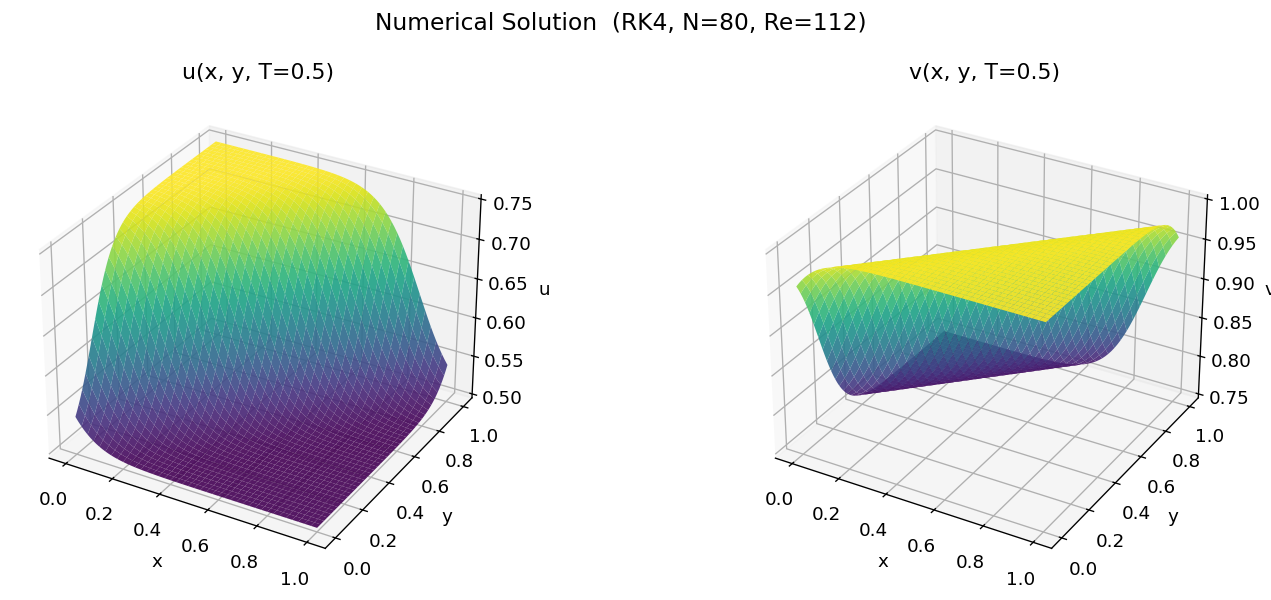

In [8]:
# 3D surface plots
fig, axes = plt.subplots(1, 2, figsize=(13, 5), subplot_kw={'projection': '3d'})
for ax, field, name in zip(axes, [u, v], ['u', 'v']):
    ax.plot_surface(X, Y, field, cmap=cm.viridis, alpha=0.9,
                    rstride=2, cstride=2, linewidth=0)
    ax.set_xlabel('x');  ax.set_ylabel('y');  ax.set_zlabel(name)
    ax.set_title(f'{name}(x, y, T={T})')
fig.suptitle(f'Numerical Solution  (RK4, N={N_ref}, Re={Re:.0f})', fontsize=14)
plt.tight_layout();  plt.show()

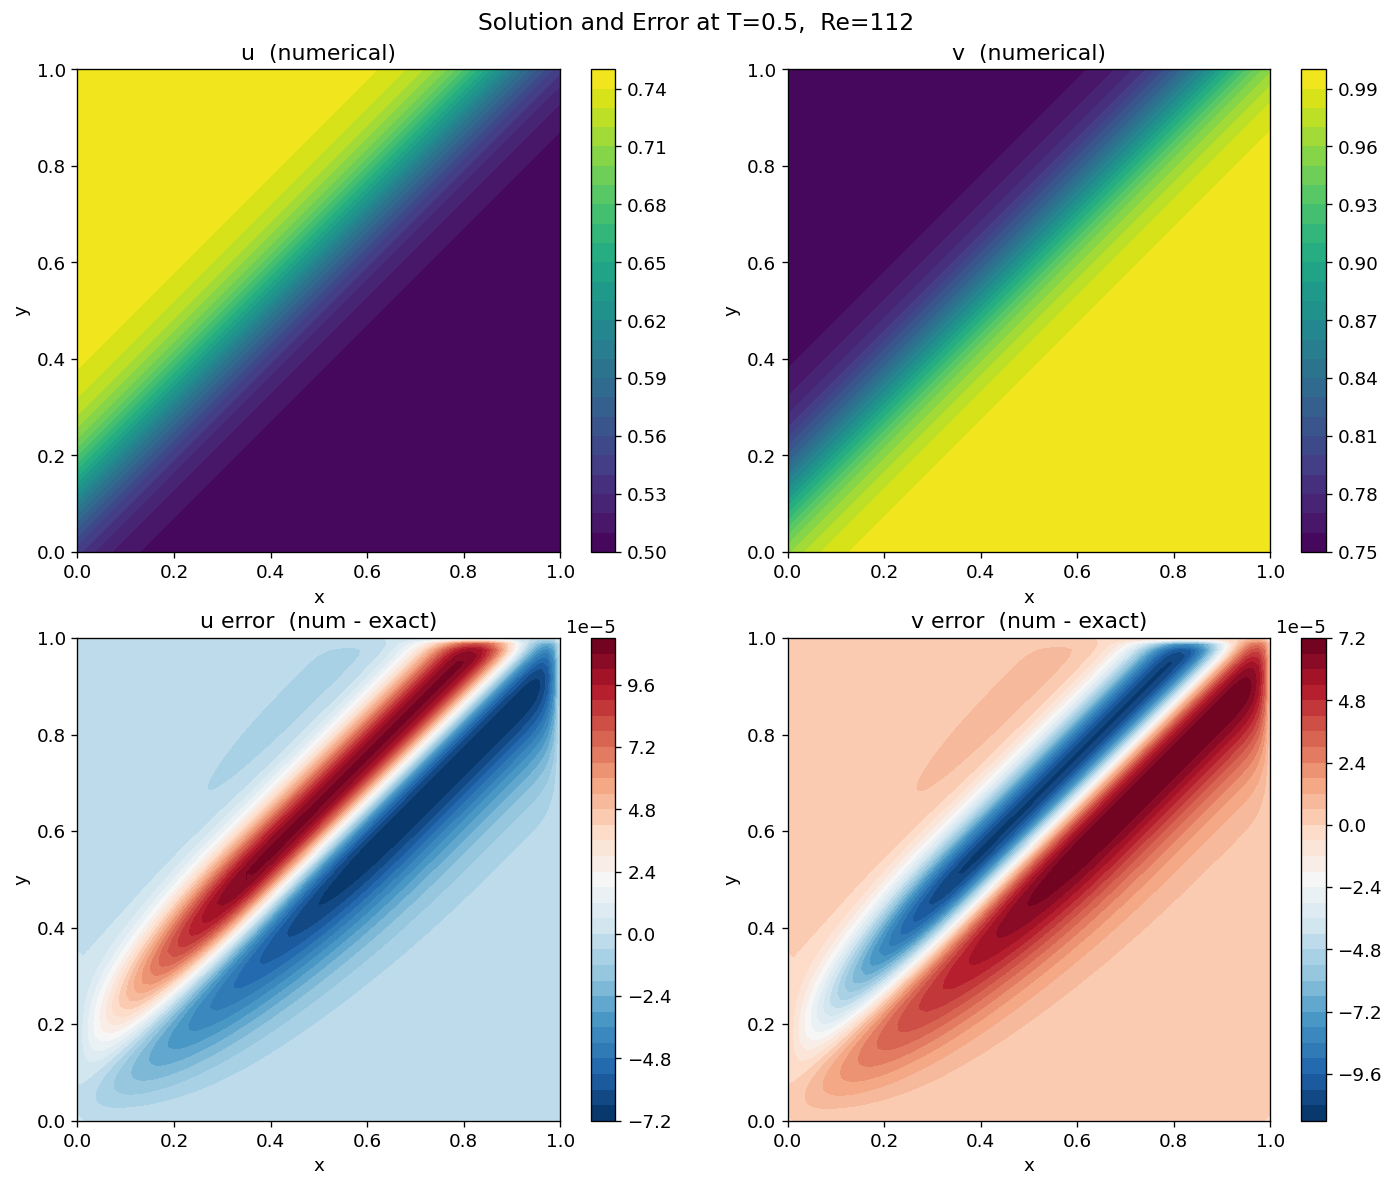

In [9]:
# Contour: numerical solution and pointwise error
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

c1 = axes[0,0].contourf(X, Y, u, levels=30, cmap=cm.viridis)
axes[0,0].set_title('u  (numerical)');  plt.colorbar(c1, ax=axes[0,0])
c2 = axes[0,1].contourf(X, Y, v, levels=30, cmap=cm.viridis)
axes[0,1].set_title('v  (numerical)');  plt.colorbar(c2, ax=axes[0,1])

c3 = axes[1,0].contourf(X, Y, u - ue, levels=30, cmap=cm.RdBu_r)
axes[1,0].set_title('u error  (num - exact)');  plt.colorbar(c3, ax=axes[1,0])
c4 = axes[1,1].contourf(X, Y, v - ve, levels=30, cmap=cm.RdBu_r)
axes[1,1].set_title('v error  (num - exact)');  plt.colorbar(c4, ax=axes[1,1])

for ax in axes.flat:
    ax.set_xlabel('x');  ax.set_ylabel('y');  ax.set_aspect('equal')
fig.suptitle(f'Solution and Error at T={T},  Re={Re:.0f}', fontsize=14)
plt.tight_layout();  plt.show()

### 3.2 Spatial Convergence

We refine $h$ and choose $\Delta t$ from an accuracy-driven formula, capped by the RK4 CFL bound, so every run stays stable while temporal error remains negligible relative to the spatial error.

In [10]:
Ns = [10, 20, 40, 80, 160]
space_results = {}

for adv in ['central', 'upwind']:
    key = f'RK4 + {adv}'
    results = []
    for N in Ns:
        X0, Y0, h = make_grid(N)
        u0, v0 = exact_solution(X0, Y0, 0.0, nu)
        cfl_info = rk4_cfl_limits(u0, v0, nu, h, adv_type=adv)
        dt = min(0.5 * h**2 / (4*nu + 1.0), cfl_info['dt_cfl'])
        _, _, _, _, inf = solve(N, nu, T, dt, 'rk4', adv)
        results.append(inf)
        print(
            f"  {key}  N={N:4d}  h={h:.4e}  dt={inf['dt']:.2e}  "
            f"CFL={inf['dt_cfl']:.2e} ({inf['limiter']})  err={inf['err']:.4e}  "
            f"wall={inf['wall']:.2f}s"
        )
    space_results[key] = results
    for i in range(1, len(results)):
        rate = np.log(results[i-1]['err']/results[i]['err']) / np.log(2)
        print(f"    rate N={Ns[i-1]}->{Ns[i]}: {rate:.2f}")
    print()

  RK4 + central  N=  10  h=1.0000e-01  dt=4.81e-03  CFL=1.70e-01 (advection)  err=2.7044e-03  wall=0.04s
  RK4 + central  N=  20  h=5.0000e-02  dt=1.20e-03  CFL=7.83e-02 (diffusion)  err=6.1669e-04  wall=0.17s
  RK4 + central  N=  40  h=2.5000e-02  dt=3.00e-04  CFL=1.96e-02 (diffusion)  err=1.4877e-04  wall=1.25s
  RK4 + central  N=  80  h=1.2500e-02  dt=7.51e-05  CFL=4.90e-03 (diffusion)  err=3.6829e-05  wall=11.56s
  RK4 + central  N= 160  h=6.2500e-03  dt=1.88e-05  CFL=1.22e-03 (diffusion)  err=9.1839e-06  wall=163.74s
    rate N=10->20: 2.13
    rate N=20->40: 2.05
    rate N=40->80: 2.01
    rate N=80->160: 2.00

  RK4 + upwind  N=  10  h=1.0000e-01  dt=4.81e-03  CFL=6.00e-02 (advection)  err=1.9907e-02  wall=0.05s
  RK4 + upwind  N=  20  h=5.0000e-02  dt=1.20e-03  CFL=3.00e-02 (advection)  err=1.3035e-02  wall=0.24s
  RK4 + upwind  N=  40  h=2.5000e-02  dt=3.00e-04  CFL=1.50e-02 (advection)  err=7.8036e-03  wall=1.58s
  RK4 + upwind  N=  80  h=1.2500e-02  dt=7.51e-05  CFL=4.90e-0

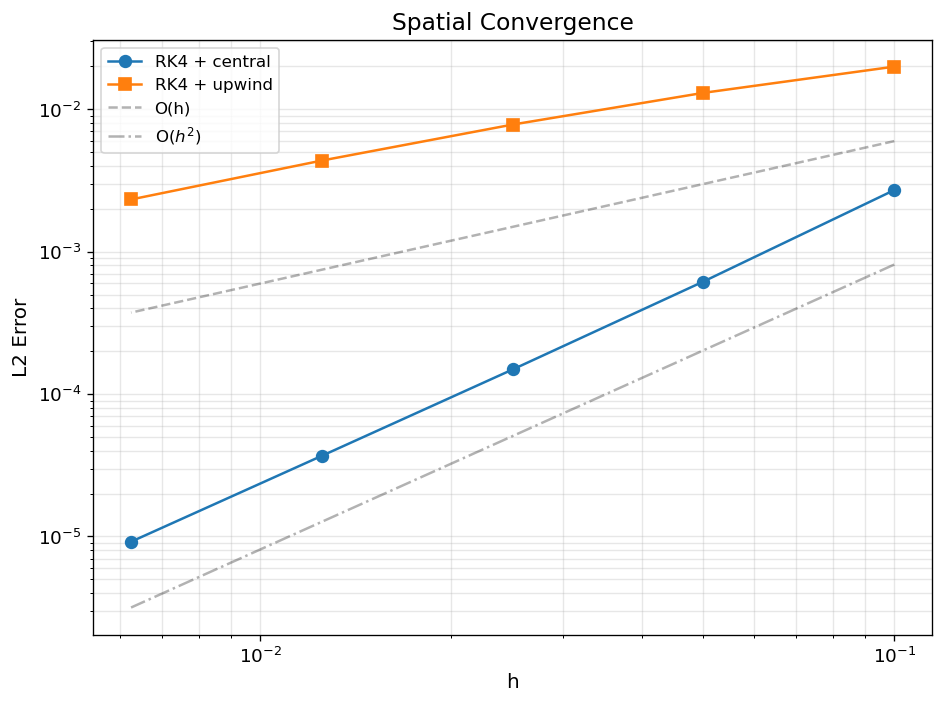

In [11]:
# Spatial convergence plot
fig, ax = plt.subplots(figsize=(8, 6))
markers = ['o', 's']
for i, (label, res) in enumerate(space_results.items()):
    hs = [r['h'] for r in res];  errs = [r['err'] for r in res]
    ax.loglog(hs, errs, f'-{markers[i]}', label=label, markersize=7, lw=1.5)

h_arr = np.array([r['h'] for r in list(space_results.values())[0]])
ax.loglog(h_arr, 0.3*(h_arr/h_arr[0])**1 * list(space_results.values())[1][0]['err'],
          'k--', alpha=0.3, label='O(h)')
ax.loglog(h_arr, 0.3*(h_arr/h_arr[0])**2 * list(space_results.values())[0][0]['err'],
          'k-.', alpha=0.3, label=r'O($h^2$)')
ax.set_xlabel('h', fontsize=12);  ax.set_ylabel('L2 Error', fontsize=12)
ax.set_title('Spatial Convergence', fontsize=14)
ax.legend(fontsize=10);  ax.grid(True, which='both', alpha=0.3)
plt.tight_layout();  plt.show()

### 3.3 Temporal Convergence

We fix $N=40$ and vary $\Delta t$. Temporal error is isolated by comparing against a same-grid RK4 reference with $\Delta t = 10^{-4}$. For RK4, the solver rejects requested step sizes that already exceed the initial-state CFL estimate before marching.

| Method | Expected Rate |
|--------|---------------|
| Forward Euler | $O(\Delta t)$ |
| RK4 | $O(\Delta t^4)$ |
| Backward Euler (semi-implicit) | $O(\Delta t)$ |
| Crank-Nicolson (predictor-corrector) | $O(\Delta t^2)$ |

In [12]:
N_t = 40
h_t = 1.0 / N_t
X_t, Y_t, _ = make_grid(N_t)
u0_t, v0_t = exact_solution(X_t, Y_t, 0.0, nu)
rk4_time_cfl = rk4_cfl_limits(u0_t, v0_t, nu, h_t)

print(
    f"RK4 CFL limit on N={N_t}: dt_cfl={rk4_time_cfl['dt_cfl']:.4e} "
    f"(dt_adv={rk4_time_cfl['dt_adv']:.4e}, dt_diff={rk4_time_cfl['dt_diff']:.4e}, "
    f"{rk4_time_cfl['limiter']}-limited)\n"
)

# Reference solution (same grid, tiny dt)
u_ref, v_ref, _, _, _ = solve(N_t, nu, T, dt=1e-4, method='rk4')


def temporal_error(method, dt):
    u_n, v_n, _, _, inf = solve(N_t, nu, T, dt, method=method)
    e = np.sqrt(h_t**2 * np.sum((u_n - u_ref)**2 + (v_n - v_ref)**2))
    return e, inf


time_results = {}
configs = [
    ('euler', [0.01, 0.005, 0.0025, 0.00125]),
    ('rk4',   [0.01, 0.005, 0.0025, 0.00125]),
    ('be',    [0.05, 0.025, 0.0125, 0.00625]),
    ('cn',    [0.05, 0.025, 0.0125, 0.00625]),
]

for meth, dts in configs:
    name = METHOD_NAMES[meth]
    res_list = []
    print(f"{name}:")
    for dt in dts:
        e, inf = temporal_error(meth, dt)
        inf['terr'] = e
        res_list.append(inf)
        extra = ''
        if meth == 'rk4':
            extra = f"  CFL ratio={inf['dt'] / inf['dt_cfl']:.3f}"
        print(f"  dt={dt:.5f}  temporal_err={e:.4e}  wall={inf['wall']:.2f}s{extra}")
    for i in range(1, len(res_list)):
        rate = np.log(res_list[i-1]['terr']/res_list[i]['terr']) / np.log(dts[i-1]/dts[i])
        print(f"  rate: {rate:.2f}")
    time_results[name] = res_list
    print()

RK4 CFL limit on N=40: dt_cfl=1.9584e-02 (dt_adv=4.7140e-02, dt_diff=2.1760e-02, diffusion-limited)

Forward Euler:
  dt=0.01000  temporal_err=2.4197e-04  wall=0.01s
  dt=0.00500  temporal_err=1.2020e-04  wall=0.02s
  dt=0.00250  temporal_err=5.9910e-05  wall=0.03s
  dt=0.00125  temporal_err=2.9908e-05  wall=0.07s
  rate: 1.01
  rate: 1.00
  rate: 1.00

RK4:
  dt=0.01000  temporal_err=6.4246e-09  wall=0.03s  CFL ratio=0.511
  dt=0.00500  temporal_err=3.4985e-10  wall=0.07s  CFL ratio=0.255
  dt=0.00250  temporal_err=2.0418e-11  wall=0.14s  CFL ratio=0.128
  dt=0.00125  temporal_err=1.2333e-12  wall=0.27s  CFL ratio=0.064
  rate: 4.20
  rate: 4.10
  rate: 4.05

Backward Euler:
  dt=0.05000  temporal_err=2.1310e-03  wall=0.00s
  dt=0.02500  temporal_err=1.0384e-03  wall=0.01s
  dt=0.01250  temporal_err=5.1299e-04  wall=0.02s
  dt=0.00625  temporal_err=2.5500e-04  wall=0.04s
  rate: 1.04
  rate: 1.02
  rate: 1.01

Crank-Nicolson:
  dt=0.05000  temporal_err=7.1195e-05  wall=0.01s
  dt=0.02

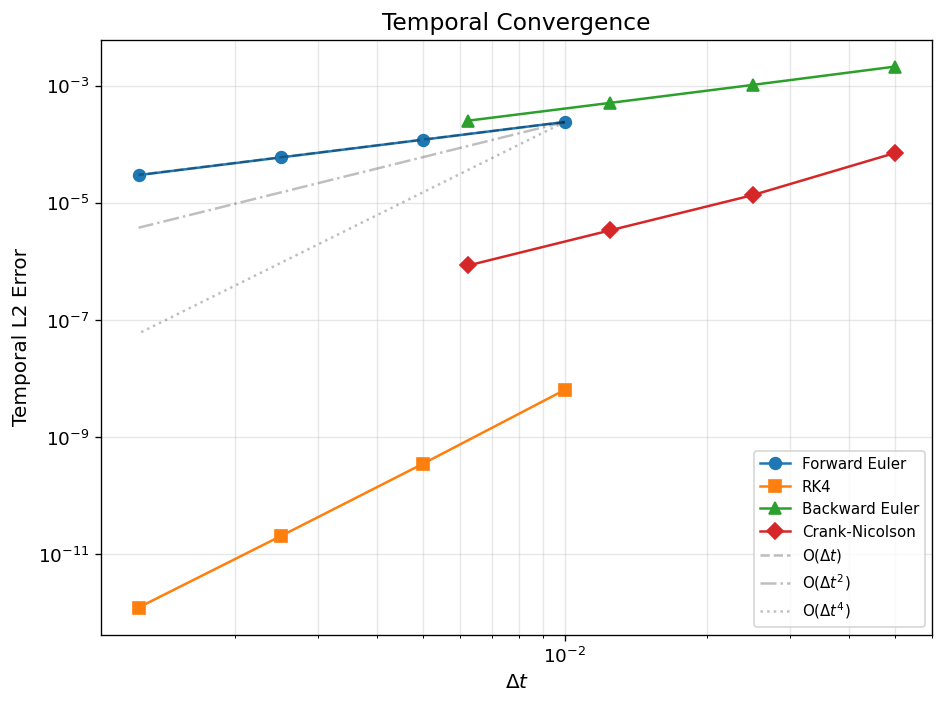

In [13]:
# Temporal convergence plot
fig, ax = plt.subplots(figsize=(8, 6))
markers = ['o', 's', '^', 'D']
for i, (label, res) in enumerate(time_results.items()):
    dts = [r['dt'] for r in res];  errs = [r['terr'] for r in res]
    ax.loglog(dts, errs, f'-{markers[i]}', label=label, markersize=7, lw=1.5)

# Reference slopes
dt0 = np.array([r['dt'] for r in list(time_results.values())[0]])
e0 = list(time_results.values())[0][0]['terr']
ax.loglog(dt0, e0*(dt0/dt0[0])**1, 'k--', alpha=0.25, label=r'O($\Delta t$)')
ax.loglog(dt0, e0*(dt0/dt0[0])**2, 'k-.', alpha=0.25, label=r'O($\Delta t^2$)')
ax.loglog(dt0, e0*(dt0/dt0[0])**4, 'k:', alpha=0.25, label=r'O($\Delta t^4$)')

ax.set_xlabel(r'$\Delta t$', fontsize=12);  ax.set_ylabel('Temporal L2 Error', fontsize=12)
ax.set_title('Temporal Convergence', fontsize=14)
ax.legend(fontsize=9);  ax.grid(True, which='both', alpha=0.3)
plt.tight_layout();  plt.show()

### 3.4 Cost vs. Accuracy

For practical use, we care about *error per unit of compute time*. Implicit methods allow larger $\Delta t$ but each step costs more (sparse LU solve). RK4 has 4 RHS evaluations per step but achieves $O(\Delta t^4)$ accuracy.

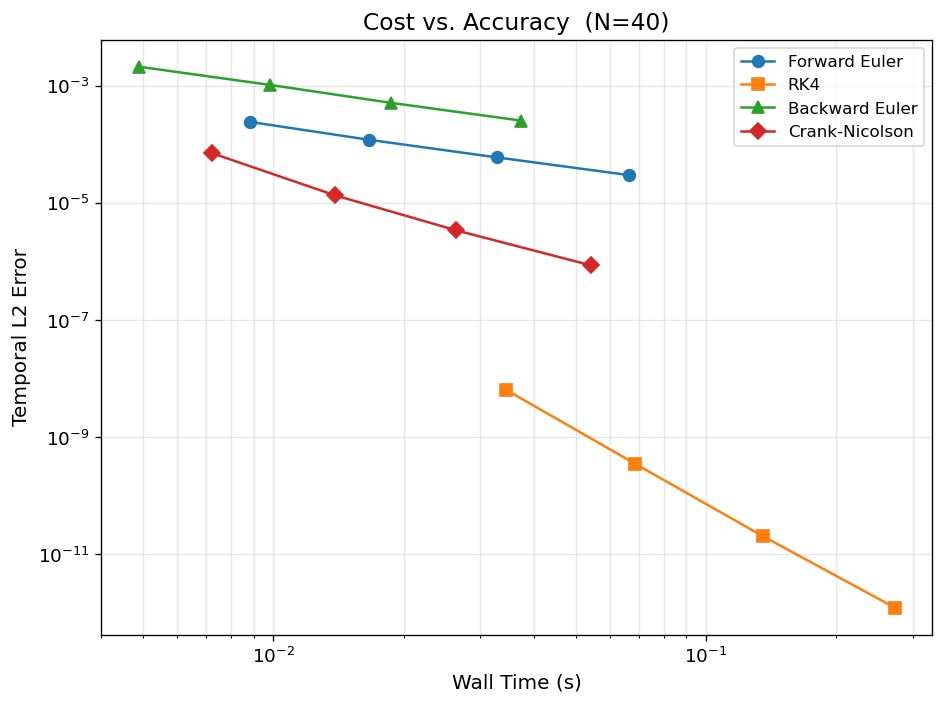

In [14]:
# Cost vs accuracy
fig, ax = plt.subplots(figsize=(8, 6))
markers = ['o', 's', '^', 'D']
for i, (label, res) in enumerate(time_results.items()):
    walls = [r['wall'] for r in res];  errs = [r['terr'] for r in res]
    ax.loglog(walls, errs, f'-{markers[i]}', label=label, markersize=7, lw=1.5)

ax.set_xlabel('Wall Time (s)', fontsize=12);  ax.set_ylabel('Temporal L2 Error', fontsize=12)
ax.set_title('Cost vs. Accuracy  (N=40)', fontsize=14)
ax.legend(fontsize=10);  ax.grid(True, which='both', alpha=0.3)
plt.tight_layout();  plt.show()

### 3.5 Stability Boundary (Forward Euler vs RK4)

For Forward Euler with central differences in 2D, the classical diffusion restriction is
$$\Delta t \le \frac{h^2}{4\nu}.$$
This is a diffusion-based guideline; once explicit central advection is included, the full scheme does not inherit a simple standalone stability theorem from that formula alone.

For classical RK4, the stability interval extends farther along the negative real axis, giving the diffusion estimate
$$\Delta t \lesssim \frac{2.785\,h^2}{8\nu} \approx 1.39\,\frac{h^2}{4\nu},$$
and we also monitor the advective estimate
$$\Delta t \le \frac{C_{\mathrm{adv}} h}{\max(|u|+|v|)},$$
with $C_{\mathrm{adv}} = 2\sqrt{2}$ for central advection and a more conservative empirical choice $C_{\mathrm{adv}} = 1$ for upwind advection.

The sweep below should therefore be interpreted as an empirical blow-up study for this viscous Burgers setup, not as a proof of sharp stability boundaries for every explicit discretization.

Forward Euler: N = 80,  h = 0.0125,  dt_limit = h^2/(4*nu) = 3.9063e-03
RK4:           N = 80,  h = 0.0125,  dt_limit = 5.4400e-03 (dt_adv = 2.3570e-02, dt_diff = 5.4400e-03, diffusion-limited)

Forward Euler:
  dt/dt_limit = 0.10  -->  STABLE
  dt/dt_limit = 0.20  -->  STABLE
  dt/dt_limit = 0.30  -->  STABLE
  dt/dt_limit = 0.40  -->  STABLE
  dt/dt_limit = 0.50  -->  STABLE
  dt/dt_limit = 0.60  -->  STABLE
  dt/dt_limit = 0.70  -->  STABLE
  dt/dt_limit = 0.80  -->  STABLE
  dt/dt_limit = 0.90  -->  STABLE
  dt/dt_limit = 1.00  -->  STABLE
  dt/dt_limit = 1.10  -->  STABLE
  dt/dt_limit = 1.20  -->  UNSTABLE
  dt/dt_limit = 1.30  -->  UNSTABLE
  dt/dt_limit = 1.40  -->  UNSTABLE
  dt/dt_limit = 1.50  -->  UNSTABLE
  dt/dt_limit = 1.60  -->  UNSTABLE
  dt/dt_limit = 1.70  -->  UNSTABLE
  dt/dt_limit = 1.80  -->  UNSTABLE
  dt/dt_limit = 1.90  -->  UNSTABLE
  dt/dt_limit = 2.00  -->  UNSTABLE

RK4:
  dt/dt_limit = 0.10  -->  STABLE
  dt/dt_limit = 0.20  -->  STABLE
  dt/dt_limit = 0.

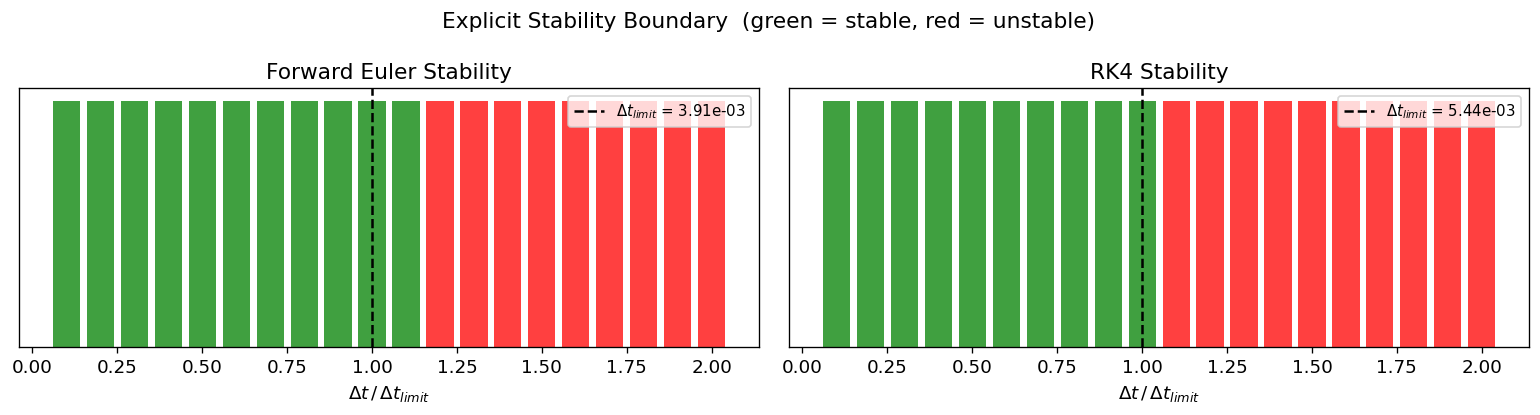

In [15]:
N_stab = 80
h_stab = 1.0 / N_stab
X_stab, Y_stab, _ = make_grid(N_stab)
u0_stab, v0_stab = exact_solution(X_stab, Y_stab, 0.0, nu)
rk4_stab_info = rk4_cfl_limits(u0_stab, v0_stab, nu, h_stab, cfl=1.0)

print(f"Forward Euler: N = {N_stab},  h = {h_stab:.4f},  dt_limit = h^2/(4*nu) = {h_stab**2 / (4*nu):.4e}")
print(
    f"RK4:           N = {N_stab},  h = {h_stab:.4f},  dt_limit = {rk4_stab_info['dt_cfl']:.4e} "
    f"(dt_adv = {rk4_stab_info['dt_adv']:.4e}, dt_diff = {rk4_stab_info['dt_diff']:.4e}, "
    f"{rk4_stab_info['limiter']}-limited)\n"
)

stab_results = {}
for method in ['euler', 'rk4']:
    name = METHOD_NAMES[method]
    results, dt_limit = probe_explicit_stability(N_stab, nu, T, method=method)
    stab_results[method] = (results, dt_limit)
    print(name + ':')
    for item in results:
        print(f"  dt/dt_limit = {item['ratio']:.2f}  -->  {'STABLE' if item['stable'] else 'UNSTABLE'}")
    print()

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5), sharey=True)
for ax, method in zip(axes, ['euler', 'rk4']):
    name = METHOD_NAMES[method]
    results, dt_limit = stab_results[method]
    for item in results:
        ax.bar(item['ratio'], 1, width=0.08,
               color='green' if item['stable'] else 'red', alpha=0.75)
    ax.axvline(x=1.0, color='black', ls='--', lw=1.5, label=f'$\\Delta t_{{limit}}$ = {dt_limit:.2e}')
    ax.set_xlabel(r'$\Delta t \, / \, \Delta t_{limit}$', fontsize=11)
    ax.set_title(f'{name} Stability', fontsize=13)
    ax.set_yticks([])
    ax.legend(fontsize=9)

fig.suptitle('Explicit Stability Boundary  (green = stable, red = unstable)', fontsize=13)
plt.tight_layout()
plt.show()

### 3.6 Effect of Viscosity (Reynolds Number Sweep)

As $\nu \to 0$ (i.e., $\text{Re} \to \infty$), the solution develops sharp gradients resembling shocks. This tests whether the numerical method can resolve steep fronts and highlights when finer grids or upwinding become necessary.

  nu=0.1000  Re=11  dt=4.89e-04  CFL=4.90e-04 (diffusion)  err=7.9233e-08  steps=1022  wall=1.82s
  nu=0.0100  Re=112  dt=1.00e-03  CFL=4.90e-03 (diffusion)  err=3.6829e-05  steps=500  wall=0.94s
  nu=0.0050  Re=224  dt=1.00e-03  CFL=9.79e-03 (diffusion)  err=1.5828e-04  steps=500  wall=0.88s
  nu=0.0010  Re=1125  dt=1.00e-03  CFL=2.12e-02 (advection)  err=3.3776e-03  steps=500  wall=0.89s


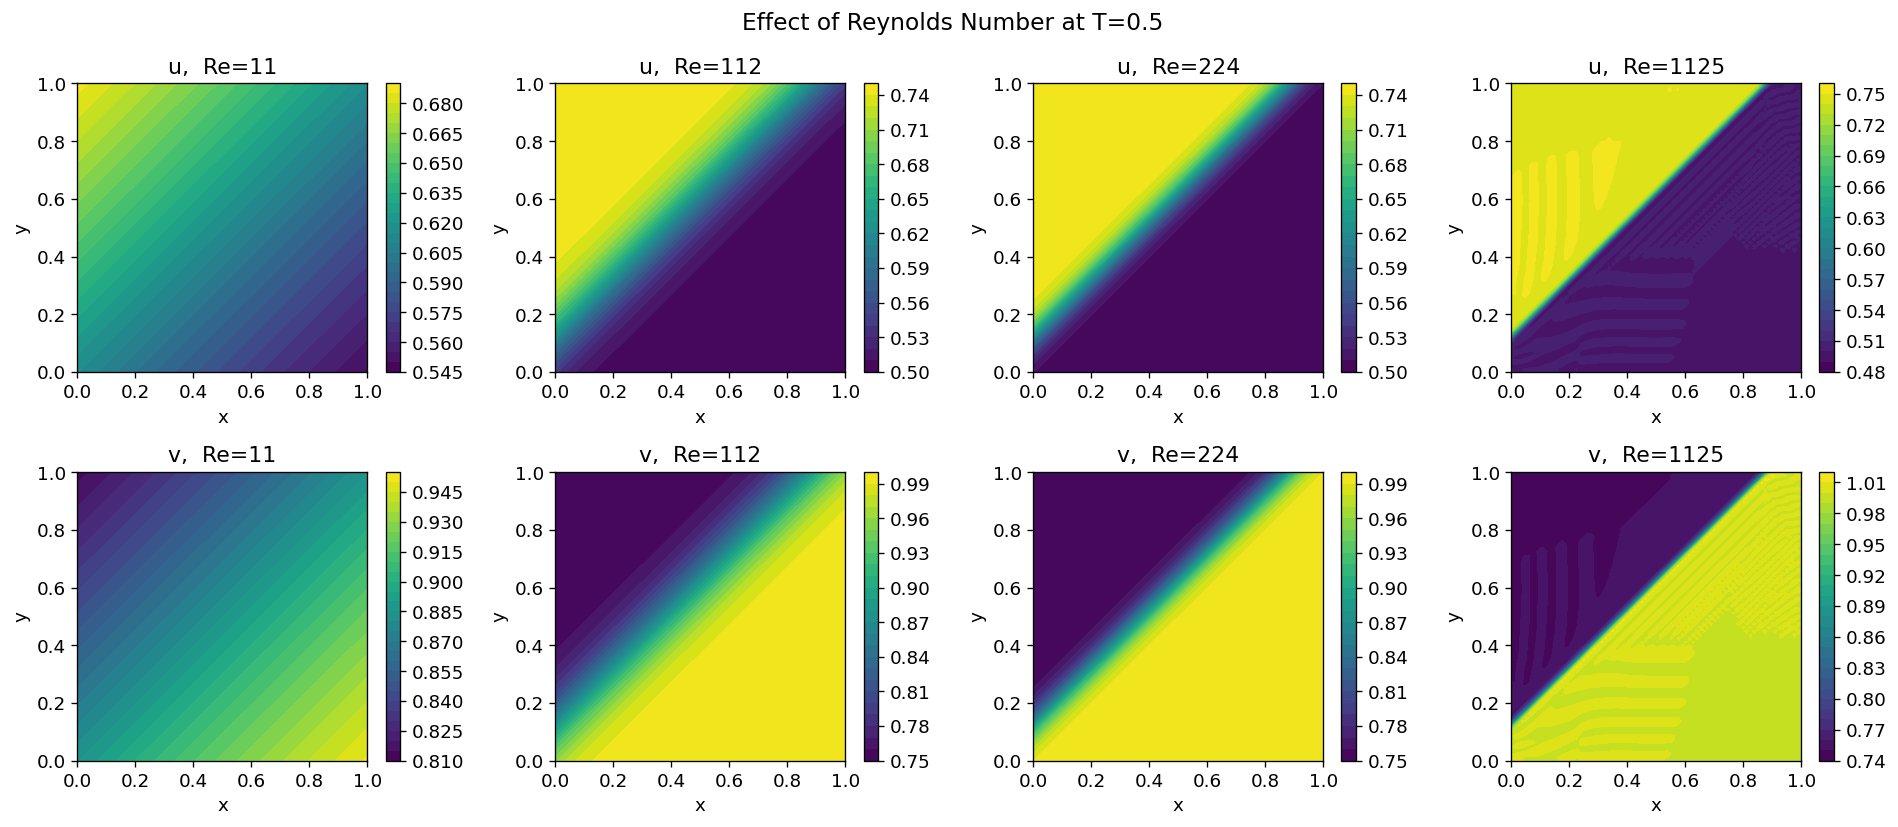

In [16]:
nus_sweep = [0.1, 0.01, 0.005, 0.001]
N_sw = 80

fig, axes = plt.subplots(2, len(nus_sweep), figsize=(4*len(nus_sweep), 7))

for j, nu_val in enumerate(nus_sweep):
    X_sw, Y_sw, h_sw = make_grid(N_sw)
    u0_sw, v0_sw = exact_solution(X_sw, Y_sw, 0.0, nu_val)
    cfl_sw = rk4_cfl_limits(u0_sw, v0_sw, nu_val, h_sw)
    dt_sw = min(0.001, cfl_sw['dt_cfl'])
    u_sw, v_sw, X_sw, Y_sw, inf_sw = solve(N_sw, nu_val, T, dt_sw, 'rk4')
    U_sw = np.max(np.sqrt(u_sw**2 + v_sw**2))
    Re_sw = U_sw / nu_val
    print(
        f"  nu={nu_val:.4f}  Re={Re_sw:.0f}  dt={inf_sw['dt']:.2e}  "
        f"CFL={inf_sw['dt_cfl']:.2e} ({inf_sw['limiter']})  err={inf_sw['err']:.4e}  "
        f"steps={inf_sw['nsteps']}  wall={inf_sw['wall']:.2f}s"
    )

    c1 = axes[0, j].contourf(X_sw, Y_sw, u_sw, levels=30, cmap=cm.viridis)
    axes[0, j].set_title(f'u,  Re={Re_sw:.0f}')
    plt.colorbar(c1, ax=axes[0, j])
    axes[0, j].set_xlabel('x')
    axes[0, j].set_ylabel('y')

    c2 = axes[1, j].contourf(X_sw, Y_sw, v_sw, levels=30, cmap=cm.viridis)
    axes[1, j].set_title(f'v,  Re={Re_sw:.0f}')
    plt.colorbar(c2, ax=axes[1, j])
    axes[1, j].set_xlabel('x')
    axes[1, j].set_ylabel('y')

fig.suptitle(f'Effect of Reynolds Number at T={T}', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Reflections

### What we learned

1. **Central vs. upwind advection:** Central differences give $O(h^2)$ convergence on this smooth solution. Upwind is only $O(h)$ asymptotically; on the tested grids the measured rates trend upward toward first order rather than landing exactly on it from the coarsest mesh.

2. **Semi-implicit splitting degrades order:** A naive Crank-Nicolson scheme that treats advection with Forward Euler is only $O(\Delta t)$, even though CN diffusion is $O(\Delta t^2)$. A predictor-corrector step is needed to recover second-order accuracy -- the weakest link determines the overall order.

3. **RK4 dominates for explicit methods in this test:** Despite needing 4 RHS evaluations per step, RK4's $O(\Delta t^4)$ accuracy means far fewer steps are needed to reach a given error, making it cheaper than Forward Euler over the error range sampled here.

4. **Implicit cost amortization depends on problem size:** Pre-factoring the Laplacian matrix (LU decomposition via Kronecker products) is done once and reused every step. On these grid sizes this makes the per-step cost of BE/CN competitive while allowing much larger $\Delta t$, but the tradeoff should still be checked again on larger systems.

5. **Reynolds number controls difficulty:** As $\text{Re}$ increases, the solution develops sharper internal layers, so the grid must be refined to resolve them. Once $h$ is reduced, the explicit RK4 restriction
$$
\Delta t \le \min\!\left(\frac{C_{\mathrm{adv}} h}{\max(|u|+|v|)},\; \frac{2.785\,h^2}{8\nu}\right)
$$
shrinks rapidly. In this notebook, that bound is used as a conservative initial-state estimate with $C_{\mathrm{adv}} = 2\sqrt{2}$ for central advection and an empirical $C_{\mathrm{adv}} = 1$ for upwind advection.

### What worked well
- The Cole-Hopf exact solution enabled clean verification: the central-space and temporal studies matched the expected orders well, and the upwind study showed the expected drift toward first-order behavior on refined grids.
- Kronecker-product construction of the 2D Laplacian kept the implicit solvers efficient and the code clean.
- The RK4 CFL check made the explicit studies safer and more interpretable.
- The predictor-corrector approach for CN cleanly recovered $O(\Delta t^2)$ without a fully nonlinear solve.

### Limitations and future directions
- **Forward Euler stability wording:** The reported $h^2/(4\nu)$ threshold is best read as a diffusion restriction for this viscous setup, not a complete stability theorem once central advection is present explicitly.
- **Higher-order spatial stencils:** Compact or spectral-like finite differences could improve spatial accuracy beyond $O(h^2)$ without much added cost.
- **Adaptive time stepping:** Embedding error estimates (e.g., RK4-5 pairs) to automatically select $\Delta t$ based on local error.
- **WENO for low viscosity:** When $\nu \to 0$ and shocks form, ENO/WENO schemes from the finite volume framework would avoid Gibbs-type oscillations near discontinuities.
- **Multigrid / iterative solvers:** For very large grids, direct LU becomes memory-bound; multigrid V-cycles for the Laplacian would reduce solve cost to $O(N^2)$.
- **Extension to Navier-Stokes:** The semi-implicit IMEX framework here (explicit advection, implicit diffusion) is the standard starting point for incompressible NS solvers -- adding a pressure-Poisson step is the natural next step.